In [1]:
from dotenv import load_dotenv
from typing_extensions import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode
import os
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

/Users/rahultiwari/Documents/02_Freelancing/Hachion_batch/ai_engineering_19th_may/ai-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


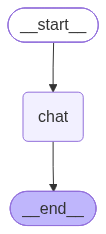

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node(state: ChatState):
    reply = llm.invoke(state["messages"])
    return {"messages": [reply]}

builder = StateGraph(ChatState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile()
graph

In [4]:
graph.invoke({"messages": [HumanMessage(content="Hi, I am Rahul.")]})

{'messages': [HumanMessage(content='Hi, I am Rahul.', additional_kwargs={}, response_metadata={}, id='cf6f4830-5f32-4c6b-82d6-f628f6dd8a30'),
  AIMessage(content='Hi Rahul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ba6e3550a6', 'id': 'chatcmpl-EOCPUXmXdKFXeUCpcz4g8tVLd6VrL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2b6-cb3b-7261-ba37-789f2788dfb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [5]:
graph.invoke({"messages": [HumanMessage(content="what is my name.")]})


{'messages': [HumanMessage(content='what is my name.', additional_kwargs={}, response_metadata={}, id='ae737061-714c-480a-a5d1-8a71fe34de02'),
  AIMessage(content="I'm sorry, but I don't have access to personal information about users unless it has been shared with me in the course of our conversation. If you'd like, you can tell me your name!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 12, 'total_tokens': 50, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b5bcb8c07e', 'id': 'chatcmpl-EOCPeBB7YGk4TUqUoA8wlGBVyhwZo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2b6-f0c6-7e33-b307-a398b72609c1-0', tool_calls=[], invalid_tool_c

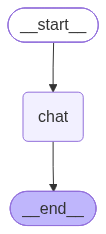

In [7]:
builder = StateGraph(ChatState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
memory= MemorySaver()
agent = builder.compile(checkpointer=memory)
agent

In [9]:
config_1 = {"configurable": {"thread_id": "chat-1"}}
agent.invoke({"messages": [HumanMessage(content="Hi, I am Rahul.")]}, config=config_1)

{'messages': [HumanMessage(content='Hi, I am Rahul.', additional_kwargs={}, response_metadata={}, id='9a76ae26-2e4a-40f8-a29b-4eb144a674c9'),
  AIMessage(content='Hi Rahul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ba6e3550a6', 'id': 'chatcmpl-EOCS2uei1479dQchwF9HbFt4Qmp6b', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2b9-35ed-7b11-8164-bee880d5f619-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [10]:
agent.invoke({"messages": [HumanMessage(content="who I am ")]}, config_1)


{'messages': [HumanMessage(content='Hi, I am Rahul.', additional_kwargs={}, response_metadata={}, id='9a76ae26-2e4a-40f8-a29b-4eb144a674c9'),
  AIMessage(content='Hi Rahul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ba6e3550a6', 'id': 'chatcmpl-EOCS2uei1479dQchwF9HbFt4Qmp6b', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2b9-35ed-7b11-8164-bee880d5f619-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [11]:
agent.invoke({"messages": [HumanMessage(content="suggest some good name for me ")]}, config_1)


{'messages': [HumanMessage(content='Hi, I am Rahul.', additional_kwargs={}, response_metadata={}, id='9a76ae26-2e4a-40f8-a29b-4eb144a674c9'),
  AIMessage(content='Hi Rahul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ba6e3550a6', 'id': 'chatcmpl-EOCS2uei1479dQchwF9HbFt4Qmp6b', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0a2b9-35ed-7b11-8164-bee880d5f619-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp